In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import sklearn as sk
from utils.flux_integration import Integrating_Flux
from utils.phase_detection import Find_Proton_Flux_Phases
import torch as tc

[Data Source](https://omniweb.gsfc.nasa.gov/ftpbrowser/soho_ephin_flux_hr.html)

# 0.1 Testing W/ Lower Fidelity Proton Data

In [2]:
proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+") 
proton_flux_df

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_14472\2513693952.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")


,Year,DOY,Hour,P4,P8,P25,P41
0,1995,342,0,0.000042,0.000020,0.000065,0.000049
1,1995,342,1,0.000028,0.000036,0.000069,0.000061
2,1995,342,2,0.000014,0.000027,0.000068,0.000073
3,1995,342,3,0.000041,0.000034,0.000069,0.000074
4,1995,342,4,0.000028,0.000027,0.000033,0.000062
...,...,...,...,...,...,...,...
53899,2002,30,19,0.114190,0.009482,0.000173,0.000050
53900,2002,30,20,0.109340,0.008745,0.000191,0.000054
53901,2002,30,21,0.108360,0.008860,0.000185,0.000046
53902,2002,30,22,0.108220,0.009084,0.000184,0.000053


# 0.2 Power Law Spectrum
**[Torres 2025](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024SW003921)**: The 
10 MeV proton intensity is calculated from the differential fluxes in four energy (P4, P8, P25, and P41) channels through an integration over the energy. The P8 proton channel covers an energy range of 7.8–25 MeV, P25 covers 25–40.9 MeV, P41 covers 40.9–53 MeV, while the P4 channel covers 4.3–7.8 MeV. We assume that particles above the P41 channel coverage make little contribution to the integral flux of MeV protons. The integral flux is calculated by summing energy-integrated fluxes in the last three (P8, P25, and P41) channels minus the amount between 7.8 and 10 MeV, which is determined by the integration of a power-law spectrum interpolated using the differential fluxes in the first two channels (P4 and P8) and their mean energies. We use the first two channels to do the interpolation because their fluxes have relatively low error bars due to high count rates in low-energy channels.

Too find channel between 7.8- 10 MeV we fall the Power Law Scale and make use of its invariance:

$\Phi_n = \alpha \nu_n^\beta$ (1)

Using the channels P4 and P8:

$\Phi_4 = \alpha \nu_4^\beta$ (2) 

$\Phi_8 = \alpha \nu_8^\beta$ (3)

Converting frequency to energy: $\nu_n = \frac{\bar{E}_n}{h}$ (4), $h = 4.136 \times 10^{-21} \text{Mev/s}$

Rewriting (2): $\alpha = \frac{\Phi_4}{\nu_4^\beta}$

And then plugging into (3): $\Phi_8 = \Phi_4 \left(\frac{\nu_8}{\nu_4} \right)^\beta$ (5)

Solving for $\beta$: $\beta = \frac{\log [\Phi_8 / \Phi_4]}{\log [\nu_8 / \nu_4]}$

Solving for $\alpha$: $\alpha = \frac{\Phi_4}{\nu_4^\beta}$ With newly discovered $\beta$

Now we can solve the flux over any range we want using our new parameters $\alpha, \beta$: $\Phi_x = \alpha \nu_x^\beta$




In [3]:
proton_flux_df = Integrating_Flux(proton_flux_df)

c:\Users\Lewis\Documents\SWLG\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG\SWLG_Code\code\utils\flux_integration.py:40: RuntimeWarning: invalid value encountered in scalar subtract
  integral = alpha * (a_E2**(beta+1) - a_E1**(beta+1)) / (beta + 1)
c:\Users\Lewis\Documents\SWLG\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: divide by zero encountered in log
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG\SWLG_Code\code\utils\flux_integration.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = a_p4_flux / (a_p4_avg_E ** beta)
c:\Us

# 0.3 Finding Onset, Peaks, and Ends
No specific technique was explained rather the "program" will sort it. heres my attempt and i will compare with theirs

In [4]:
Find_Proton_Flux_Phases(proton_flux_df, 40, "phases_11061997_11032002")

,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,1997-11-04 06:00:00,0.066021,1997-11-04 08:00:00,16.453934,1997-11-04 09:00:00,65.405438,1997-11-05 20:00:00,1.968064,1 days 14:00:00
1,1997-11-06 12:00:00,0.852781,1997-11-06 15:00:00,15.473794,1997-11-07 00:00:00,265.177378,1997-11-09 21:00:00,1.973644,3 days 09:00:00
2,1998-04-20 11:00:00,0.026764,1998-04-20 15:00:00,10.108851,1998-04-21 10:00:00,541.485781,1998-04-25 11:00:00,1.911519,5 days 00:00:00
4,1998-05-02 14:00:00,0.142543,1998-05-02 16:00:00,17.901954,1998-05-02 19:00:00,22.527648,1998-05-04 03:00:00,1.698666,1 days 13:00:00
5,1998-05-06 07:00:00,0.196682,1998-05-06 09:00:00,200.275670,1998-05-06 09:00:00,200.275670,1998-05-07 06:00:00,1.843606,0 days 23:00:00
6,1998-11-14 05:00:00,0.007492,1998-11-14 08:00:00,15.649854,1998-11-14 13:00:00,119.723238,1998-11-21 16:00:00,0.012630,7 days 11:00:00
7,1999-04-24 14:00:00,0.014742,1999-04-24 20:00:00,11.409315,1999-04-25 01:00:00,17.585362,1999-04-25 22:00:00,1.970650,1 days 08:00:00
8,1999-06-01 21:00:00,0.528786,1999-06-02 04:00:00,14.207384,1999-06-02 06:00:00,40.824945,1999-06-04 05:00:00,1.994649,2 days 08:00:00
9,1999-06-04 07:00:00,1.681259,1999-06-04 09:00:00,15.806102,1999-06-04 11:00:00,42.120864,1999-06-06 06:00:00,1.944769,1 days 23:00:00
10,2000-02-18 10:00:00,0.542037,2000-02-18 12:00:00,12.002118,2000-02-18 12:00:00,12.002118,2000-02-18 20:00:00,1.810801,0 days 10:00:00


# 0.4 Visualization

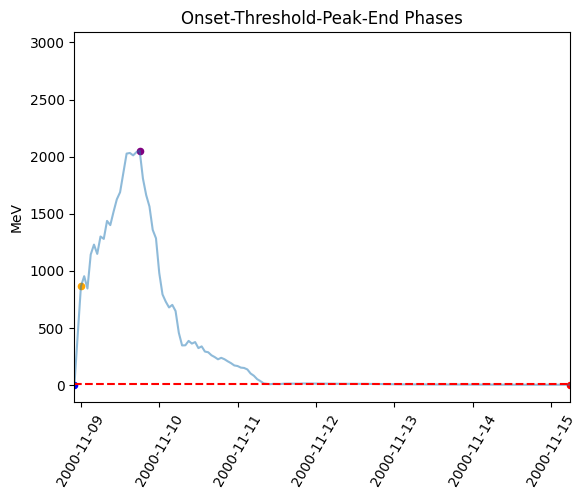

In [5]:
phase_data_df = Find_Proton_Flux_Phases(proton_flux_df, 100, "phases_11061997_11032002")

plt.title("Onset-Threshold-Peak-End Phases")
plt.ylabel("MeV")
plt.style.use("default")
plt.plot(proton_flux_df["Timestamp"], proton_flux_df["P_tot"], alpha = .5)


plt.scatter(phase_data_df["Onset Timestamp"], phase_data_df["Onset Flux"], c = "blue", s = 20 )


plt.scatter(phase_data_df["Threshold Timestamp"], phase_data_df["Threshold Flux"], c ="orange", s = 20 )

plt.scatter(phase_data_df["End Timestamp"], phase_data_df["End Flux"], c ="red", s = 20 )

plt.scatter(phase_data_df["Peak Timestamp"], phase_data_df["Peak Flux"], c = "purple", s = 20)

plt.xticks(rotation = 60)

plt.axhline(y=10, color='r', linestyle='--')
plt.xlim(
    pd.Timestamp("2000-11-08 22:00:00	"),
    pd.Timestamp("2000-11-15 06:00:00	")
)
plt.show()

# 1. Replicating Torres 2025 with Transformer M1

To form a baseline, we apply a single neural network model to the whole data set; this approach will be referred to as M1 (One Model for intensity prediction). We compare the multilayer perceptron algorithm (which from here on will be denoted as NN, or neural network) to recurrent neural networks (RNNs); RNN are designed to work with time-series data, so they are expected to perform better in this study. The Keras implementation in Python is used to create our models, with the Gated Recurrent Units (GRU) layer for the RNN model. GRU layers are described in more detail by Chung et al. (2014). Both the NN and RNN models consist of two layers: a hidden layer with 30 units, and an dense output layer with one unit. The hidden layer for the NN model is a dense layer, while the hidden layer for the RNN model is a GRU layer. During training, the neural network minimizes the loss function, which is the mean square error (MSE) between the target proton intensity and the predicted proton intensity. Similarly to the inputs, the outputs are also in the natural logarithm space, so MSE is computed in the natural logarithm space.

## 1.1 Getting Data
Gathering and mergeing all electron and proton data into one file with the same candence to easily read in our transformer model

Proton Flux Data:

Electron Flux Data:

In [6]:
from utils.merge_proton_electron import Merge_Proton_Electron
proton_path = "data/enviromental/ephin-soho/5min_proton_1997-2025/5min/"
Merge_Proton_Electron(
    proton_path="",
    e150_path="data/enviromental/ephin-soho/electron/E150_1997_2025.csv",
    e300_path="data/enviromental/ephin-soho/electron/E300_1997_2017.csv",
    output_path="data/enviromental/ephin-soho/merged"
)

Loading E150...
Loading E300...
Skipping 1997 — file not found
Skipping 1998 — file not found
Skipping 1999 — file not found
Skipping 2000 — file not found
Skipping 2001 — file not found
Skipping 2002 — file not found
Skipping 2003 — file not found
Skipping 2004 — file not found
Skipping 2005 — file not found
Skipping 2006 — file not found
Skipping 2007 — file not found
Skipping 2008 — file not found
Skipping 2009 — file not found
Skipping 2010 — file not found
Skipping 2011 — file not found
Skipping 2012 — file not found
Skipping 2013 — file not found
Skipping 2014 — file not found
Skipping 2015 — file not found
Skipping 2016 — file not found
Skipping 2017 — file not found
Skipping 2018 — file not found
Skipping 2019 — file not found
Skipping 2020 — file not found
Skipping 2021 — file not found
Skipping 2022 — file not found
Skipping 2023 — file not found
Skipping 2024 — file not found
Skipping 2025 — file not found
Done.


### 1.1.1 Filter Only Torres Relevant Years and Phases

Note on usable data: since each instance requires 2 hr of data before it and either 30 min or 1 hr after, the first 24. In each of the three approaches, the features used are the >0.25 MeV electron intensities, >0.67 MeV electron intensities, and >10 MeV proton intensities, and all are tested with and without phase inputs, with both NN and RNN algorithms.

In [7]:

torres_electron_proton_merged_df = pd.DataFrame([])

for i in range(1997, 2003, 1):
    merged_year_df = pd.read_csv('data/enviromental/ephin-soho/merged/merged_' + str(i) + '.csv')
    torres_electron_proton_merged_df = pd.concat([torres_electron_proton_merged_df, merged_year_df], ignore_index= True)

torres_merged_phases = Find_Proton_Flux_Phases(torres_electron_proton_merged_df, 50, "torres_merged_phases")


valid_df = pd.DataFrame([])
for i in range(2010, 2015, 1):  # 2010-2014 inclusive
    merged_year_df = pd.read_csv('data/enviromental/ephin-soho/merged/merged_' + str(i) + '.csv')
    valid_df = pd.concat([valid_df, merged_year_df], ignore_index=True)

valid_phases = Find_Proton_Flux_Phases(valid_df, 50, "valid_phases")


for col in ["E150", "E300", "P_tot"]:
    torres_electron_proton_merged_df[col] = np.log(
        np.clip(torres_electron_proton_merged_df[col], 1e-6, None)
    )
    valid_df[col] = np.log(
        np.clip(valid_df[col], 1e-6, None)
    )




torres_electron_proton_merged_df["Timestamp"] = pd.to_datetime(torres_electron_proton_merged_df["Timestamp"])
valid_df["Timestamp"] = pd.to_datetime(valid_df["Timestamp"])


print("Phase onset example:", valid_phases["Onset Timestamp"].iloc[0])
print("Valid df timestamp example:", valid_df["Timestamp"].iloc[0])
print("Phase dtype:", valid_phases["Onset Timestamp"].dtype)
print("Valid df dtype:", valid_df["Timestamp"].dtype)

valid_phases


Phase onset example: 2010-08-14 11:05:00
Valid df timestamp example: 2010-01-01 01:45:00
Phase dtype: datetime64[us]
Valid df dtype: datetime64[us]


,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,2010-08-14 11:05:00,0.364550,2010-08-14 12:10:00,13.093835,2010-08-14 12:35:00,17.569534,2010-08-14 19:30:00,1.939120,0 days 08:25:00
1,2011-03-07 22:50:00,1.182408,2011-03-07 23:50:00,14.502285,2011-03-08 03:35:00,41.295397,2011-03-10 15:50:00,1.945153,2 days 17:00:00
10,2011-06-07 08:45:00,1.511793,2011-06-07 11:05:00,12.073225,2011-06-07 11:20:00,15.537087,2011-06-09 13:35:00,1.978324,2 days 04:50:00
14,2011-08-04 05:15:00,0.222352,2011-08-04 05:40:00,12.966669,2011-08-04 09:40:00,61.949858,2011-08-06 05:40:00,1.848637,2 days 00:25:00
20,2011-08-09 08:30:00,0.206801,2011-08-09 08:55:00,10.575222,2011-08-09 11:50:00,20.538604,2011-08-10 01:10:00,1.997718,0 days 16:40:00
21,2011-09-23 04:15:00,1.774290,2011-09-26 05:10:00,12.424186,2011-09-26 05:10:00,12.424186,2011-09-27 16:30:00,1.976321,4 days 12:15:00
27,2012-01-23 05:15:00,1.169035,2012-01-23 05:35:00,14.017670,2012-01-23 05:45:00,25.288019,2012-02-01 04:25:00,1.835348,8 days 23:10:00
56,2012-03-07 06:25:00,1.430697,2012-03-07 07:25:00,15.505167,2012-03-07 09:30:00,150.635670,2012-03-15 13:05:00,1.828106,8 days 06:40:00
88,2012-05-17 01:40:00,0.000470,2012-05-17 04:55:00,18.791499,2012-05-17 06:30:00,28.230994,2012-05-19 00:35:00,1.920029,1 days 22:55:00
90,2012-07-07 02:45:00,1.863180,2012-07-07 04:10:00,10.767592,2012-07-07 04:55:00,13.710010,2012-07-08 08:55:00,1.873186,1 days 06:10:00


## 1.2 Preparing Our Data For Transformer

## Define Statements

In [8]:
import yaml

with open("utils/config.yaml") as f:
    config = yaml.safe_load(f)

find_best_model  = config["file"]["find_best_model"]

n_encoder_layers = config["model"]["n_encoder_layers"]
dim_values        = config["model"]["dim_values"]
n_heads          = config["model"]["n_heads"]
dropout          = config["model"]["dropout"]
train_new_models  = config["model"]["train_new_model"]
model_name_use   = config["file"]["model_name_use"]

learning_rates             = config["training"]["learning_rates"]
n_epochs       = config["training"]["n_epochs"]
batch_sizes     = config["training"]["batch_sizes"]
electron_range = config["training"]["electron_range"]
window_size    = config["training"]["electron_range"]
num_workers    = config["training"]["num_workers"]

forecasts_out = config["data"]["forecasts_out"]
train_split       = config["data"]["train_split"]

In [9]:
from torch.utils.data import Dataset, DataLoader
class ParticleFluxDatasetM1(Dataset):

    def __init__(self, a_particle_flux_df, a_electron_range, a_forecast_out):
        self.e150 = a_particle_flux_df["E150"].values
        self.e300 = a_particle_flux_df["E300"].values
        self.p_tot = a_particle_flux_df["P_tot"].values
        self.electron_range = a_electron_range
        self.proton_instance_after = a_forecast_out

    def __len__(self):
        return self.p_tot.shape[0] - self.electron_range - self.proton_instance_after

    def __getitem__(self, idx):
        e150 = self.e150[idx : idx + self.electron_range]
        e300 = self.e300[idx : idx + self.electron_range]
        p_y  = self.p_tot[idx: idx + self.electron_range]
        
        x = tc.tensor(np.column_stack([e150, e300, p_y]), dtype=tc.float32)
        y = tc.tensor(self.p_tot[idx + self.electron_range + self.proton_instance_after], dtype=tc.float32)

        sample = {"Current_Flux_Data": x,
                  "Target_Proton_Data": y}

        return sample

## 1.3 Building Transformer

https://towardsdatascience.com/how-to-make-a-pytorch-transformer-for-time-series-forecasting-69e073d4061e/

In [10]:
import torch
import torch.nn as nn


class SEPTransformerM1(nn.Module):
    def __init__(self, input_size=3, dim_val= 32, n_heads=n_heads, 
                 n_encoder_layers=n_encoder_layers, dropout=dropout, window_size=window_size):
        super().__init__()
        
     
        self.input_layer = nn.Linear(input_size, dim_val)
        
     
        self.pos_encoding = nn.Parameter(torch.zeros(1, window_size, dim_val))
   
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim_val,
            nhead=n_heads,
            dim_feedforward=dim_val * 4,
            dropout=dropout,
            batch_first=True
        )
        
      
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)
        
        
        self.output_layer = nn.Linear(dim_val, 1)
    
    def forward(self, x):
        
        x = self.input_layer(x)       
        x = x + self.pos_encoding      
        x = self.encoder(x)           
        x = x[:, -1, :]                
        x = self.output_layer(x)       
        return x

# 1.4 Training Model on Test Data

In [11]:
split_idx = int(len(torres_electron_proton_merged_df) * train_split)
split_valid = int(len(valid_df) * .3)

train_df = torres_electron_proton_merged_df.iloc[:split_idx].reset_index(drop=True)
test_df = torres_electron_proton_merged_df.iloc[split_idx:].reset_index(drop=True)
valid_df = valid_df.iloc[:split_valid].reset_index(drop=True)


e150_mean, e150_std = train_df["E150"].mean(), train_df["E150"].std()
e300_mean, e300_std = train_df["E300"].mean(), train_df["E300"].std()
p_tot_mean, p_tot_std = train_df["P_tot"].mean(), train_df["P_tot"].std()


for df in [train_df, test_df, valid_df]:
    df["E150"] = (df["E150"] - e150_mean) / e150_std
    df["E300"] = (df["E300"] - e300_mean) / e300_std
    df["P_tot"] = (df["P_tot"] - p_tot_mean) / p_tot_std

In [ ]:
from itertools import product
from datetime import datetime
from IPython.display import clear_output
import os


if train_new_models:


    for file in os.listdir("models/"):
        file_path = os.path.join("models/", file) 

        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.remove(file_path)


    for file in os.listdir("results/"):
        file_path = os.path.join("results/",file)
        if os.path.isfile(file_path) and file_path.endswith(".csv") or os.path.islink(file_path) and file_path.endswith(".csv"):
            os.remove(file_path)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using {device}")
    MSE = nn.MSELoss()
    n_models = len(dim_values) * len(batch_sizes) * len(n_epochs) * len(learning_rates) * len(forecasts_out)
    model_counter = 1
    
    model_params_df = pd.DataFrame([])

    total_batches = 0

    a = len(dim_values)  * len(n_epochs) * len(learning_rates) * len(forecasts_out) 

    for batch in range(len(batch_sizes)):
        total_batches += (batch_sizes[batch] * a)

    

    for dv, bs, ne, lr, fo in product(range(len(dim_values)), range(len(batch_sizes)), range(len(n_epochs)), range(len(learning_rates)), range(len(forecasts_out))):
        clear_output(wait=True)
        print(f"\rCreating model {model_counter} of {n_models}", flush = True)
        dim_value = dim_values[dv]
        batch_size = batch_sizes[bs]
        n_epoch = n_epochs[ne]
        learning_rate = learning_rates[lr]
        forecast_out  = forecasts_out[fo]
        run_number = dv + bs + ne + lr + fo
        total_batches_done = 0
        
        model_name = "M1-" + str(model_counter).zfill(4)
        model_params = {
            "model_name": [model_name],
            "dim_value": [dim_value],
            "batch_size" : [batch_size],
            "n_epoch" : [n_epoch],
            "learning_rate": [learning_rate],
            "forecast_out" : [forecast_out],
        }



        train_dataset = ParticleFluxDatasetM1(train_df,electron_range, forecast_out)
        test_dataset = ParticleFluxDatasetM1(test_df, electron_range, forecast_out)
        valid_dataset = ParticleFluxDatasetM1(valid_df, electron_range, forecast_out)

        train_loader = DataLoader(train_dataset, batch_size= batch_size)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)
        valid_loader = DataLoader(valid_dataset, batch_size=batch_size)




        model = SEPTransformerM1(input_size=3, dim_val=dim_value, window_size=window_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        n_batches = len(train_loader)

        # --- Torres-style convergence: stop if loss stable over 20 epochs ---
        best_loss = float('inf')
        patience = 20
        min_delta = 1e-4
        patience_counter = 0
        best_state = None

        for epoch in range(n_epoch):     # n_epoch = 1000 ceiling
            model.train()
            total_loss = 0
            epoch_start_time = datetime.now()

            for batch_counter, batch in enumerate(train_loader, start=1):
                x = batch["Current_Flux_Data"].to(device)
                y = batch["Target_Proton_Data"].to(device)
                pred = model(x).squeeze()
                loss = MSE(pred, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

                batch_per = 100 * batch_counter / n_batches
                print(f"\rEpoch {epoch+1}/{n_epoch} | batch {batch_counter}/{n_batches} "
                      f"({batch_per:.1f}%) | running loss {total_loss/batch_counter:.4f}",
                      end="", flush=True)

            avg_loss = total_loss / n_batches
            epoch_end_time = datetime.now()

            # convergence check
            if best_loss - avg_loss > min_delta:
                best_loss = avg_loss
                patience_counter = 0
                best_state = model.state_dict()
            else:
                patience_counter += 1

            print(f"\rEpoch {epoch+1}/{n_epoch} done in "
                  f"{(epoch_end_time - epoch_start_time).total_seconds():.1f}s — "
                  f"loss {avg_loss:.4f} | best {best_loss:.4f} | "
                  f"patience {patience_counter}/{patience}" + " " * 15)

            if patience_counter >= patience:
                print(f"Converged at epoch {epoch+1} (loss stable {patience} epochs)")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        model_params["loss"] = [round(best_loss, 5)]
        print(f"saving {model_name}...")
        torch.save(model.state_dict(), 'models/' + model_name + '.pt')
        model_row_df = pd.DataFrame(model_params)
        model_params_df = pd.concat([model_params_df, model_row_df])
        model_counter += 1
print("Done!")


Creating model 2 of 2
Epoch 1/1000 done in 47.6s — loss 0.1353 | best 0.1353 | patience 0/20               
Epoch 2/1000 done in 48.1s — loss 0.0938 | best 0.0938 | patience 0/20               
Epoch 3/1000 done in 48.6s — loss 0.0756 | best 0.0756 | patience 0/20               
Epoch 4/1000 done in 48.5s — loss 0.0712 | best 0.0712 | patience 0/20               
Epoch 5/1000 done in 47.8s — loss 0.0693 | best 0.0693 | patience 0/20               
Epoch 6/1000 done in 47.7s — loss 0.0636 | best 0.0636 | patience 0/20               
Epoch 7/1000 done in 48.7s — loss 0.0616 | best 0.0616 | patience 0/20               
Epoch 8/1000 done in 48.6s — loss 0.0572 | best 0.0572 | patience 0/20               
Epoch 9/1000 done in 48.1s — loss 0.0603 | best 0.0572 | patience 1/20               
Epoch 10/1000 done in 48.2s — loss 0.0579 | best 0.0572 | patience 2/20               
Epoch 11/1000 done in 48.7s — loss 0.0545 | best 0.0545 | patience 0/20               
Epoch 12/1000 done in 49.1s — 

In [12]:
import matplotlib.dates as mdates
from utils.graph_results import Record_Overall_Results

from utils.get_rising_metrics import Get_Rising_Metrics
from utils.model import Evaluate_Models

%load_ext autoreload
%autoreload 2

results_df, results_rising_df, outputs = Evaluate_Models(
    model_params_df,
    model_class=SEPTransformerM1,
    test_loader=valid_loader,
    test_df=valid_df,
    torres_merged_phases= valid_phases,
    loss_fn=MSE,
    device=device,
    window_size=window_size,
    input_size=3,
    p_tot_std=p_tot_std,
    p_tot_mean=p_tot_mean,
    create_graphs=True,
) 

model_params_df[['o_r2', 'o_mse', 'o_mae']] = results_df[['r2', 'mse', 'mae']].values
model_params_df[['r_r2', 'r_mse', 'r_mae']] = results_rising_df[['r2', 'mse', 'mae']].values
model_params_df = model_params_df.reset_index()
now = str(datetime.now().strftime("%Y:%m:%d:%H:%M:%S"))
now = now.replace(":", "")
model_params_df.to_csv("results/model_params_"+ now + '.csv' )


NameError: name 'model_params_df' is not defined

In [ ]:
from datetime import datetime
import numpy as np
import os
import torch
from utils.model import Evaluate_Models
model_params_df = pd.read_csv('results/model_params_20260621012809.csv')
forecasts = np.unique(model_params_df['forecast_out'].values)
final_summary = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MSE = nn.MSELoss()
for f in forecasts:
    os.makedirs(f'models/best/t={f}', exist_ok=True)
    for file in os.listdir(f"models/best/t={f}"):
        fp = os.path.join(f"models/best/t={f}", file)
        if os.path.isfile(fp) or os.path.islink(fp):
            os.remove(fp)

    # --- select config for this horizon (single candidate since no real search) ---
    mpf = model_params_df[model_params_df["forecast_out"] == f].reset_index(drop=True)
    best_index = mpf['r_mae'].idxmin()
    best_model_name = mpf["model_name"].iloc[best_index]
    print(f"Selected t={f}: {best_model_name}, MAE {mpf['r_mae'].min():.3f}")

    dim_value     = int(mpf['dim_value'].iloc[best_index])
    batch_size    = int(mpf['batch_size'].iloc[best_index])
    learning_rate = mpf['learning_rate'].iloc[best_index]
    n_epoch       = 1000   # ceiling; convergence stops earlier

    seed_test_maes = []

    for seed in range(5):
        torch.manual_seed(seed)

        train_dataset = ParticleFluxDatasetM1(train_df, electron_range, f)
        train_loader  = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers)
        test_dataset  = ParticleFluxDatasetM1(test_df, electron_range, f)
        test_loader   = DataLoader(test_dataset, batch_size=batch_size)

        model = SEPTransformerM1(input_size=3, dim_val=dim_value, window_size=window_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        n_batches = len(train_loader)

        # --- Torres-style convergence ---
        best_loss = float('inf')
        patience = 20
        min_delta = 1e-4
        patience_counter = 0
        best_state = None

        for epoch in range(n_epoch):
            model.train()
            total_loss = 0
            epoch_start_time = datetime.now()

            for batch_counter, batch in enumerate(train_loader, start=1):
                x = batch["Current_Flux_Data"].to(device)
                y = batch["Target_Proton_Data"].to(device)
                pred = model(x).squeeze()
                loss = MSE(pred, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

                batch_per = 100 * batch_counter / n_batches
                print(f"\rt={f} | Seed {seed} | Epoch {epoch+1}/{n_epoch} | "
                      f"batch {batch_counter}/{n_batches} ({batch_per:.1f}%) | "
                      f"running loss {total_loss/batch_counter:.4f}",
                      end="", flush=True)

            avg_loss = total_loss / n_batches
            epoch_end_time = datetime.now()

            if best_loss - avg_loss > min_delta:
                best_loss = avg_loss
                patience_counter = 0
                best_state = model.state_dict()
            else:
                patience_counter += 1

            print(f"\rt={f} | Seed {seed} | Epoch {epoch+1}/{n_epoch} done in "
                  f"{(epoch_end_time - epoch_start_time).total_seconds():.1f}s — "
                  f"loss {avg_loss:.4f} | best {best_loss:.4f} | "
                  f"patience {patience_counter}/{patience}" + " " * 15)

            if patience_counter >= patience:
                print(f"t={f} | Seed {seed} converged at epoch {epoch+1}")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        model_name = f"{best_model_name}-seed{seed}"
        torch.save(model.state_dict(), f'models/best/t={f}/{model_name}.pt')

        # --- evaluate this seed on test, once ---
        one_model_df = pd.DataFrame([{
            "model_name": model_name, "dim_value": dim_value,
            "batch_size": batch_size, "n_epoch": n_epoch,
            "learning_rate": learning_rate, "forecast_out": f
        }])

        _, rising_df, _ = Evaluate_Models(
            one_model_df, model_class=SEPTransformerM1,
            test_loader=test_loader, test_df=test_df,
            torres_merged_phases=torres_merged_phases,
            loss_fn=MSE, device=device, window_size=window_size,
            input_size=3, p_tot_std=p_tot_std, p_tot_mean=p_tot_mean,
            models_dir=f'models/best/t={f}/', create_graphs=False,
        )
        seed_mae = rising_df['mae'].iloc[0]
        seed_test_maes.append(seed_mae)
        print(f"t={f} | Seed {seed} done — rising MAE {seed_mae:.4f}")

    seed_test_maes = np.array(seed_test_maes)
    print(f"\n=== t={f} — Test rising-phase MAE: {seed_test_maes.mean():.4f} ± {seed_test_maes.std():.4f} ===\n")
    final_summary.append({
        "forecast_out": f,
        "mean_mae": float(seed_test_maes.mean()),
        "std_mae": float(seed_test_maes.std()),
        "all_maes": list(seed_test_maes),
    })

pd.DataFrame(final_summary).to_csv("results/final_seed_summary.csv", index=False)
print("All done.")

Selected t=6: M1-0001, MAE 0.175
t=6 | Seed 0 | Epoch 1/1000 done in 49.3s — loss 0.1449 | best 0.1449 | patience 0/20               
t=6 | Seed 0 | Epoch 2/1000 done in 48.8s — loss 0.0883 | best 0.0883 | patience 0/20               
t=6 | Seed 0 | Epoch 3/1000 done in 47.9s — loss 0.0883 | best 0.0883 | patience 1/20               
t=6 | Seed 0 | Epoch 4/1000 done in 48.0s — loss 0.0667 | best 0.0667 | patience 0/20               
t=6 | Seed 0 | Epoch 5/1000 done in 48.3s — loss 0.0603 | best 0.0603 | patience 0/20               
t=6 | Seed 0 | Epoch 6/1000 done in 52.8s — loss 0.0569 | best 0.0569 | patience 0/20               
t=6 | Seed 0 | Epoch 7/1000 done in 52.9s — loss 0.0644 | best 0.0569 | patience 1/20               
t=6 | Seed 0 | Epoch 8/1000 done in 49.9s — loss 0.0547 | best 0.0547 | patience 0/20               
t=6 | Seed 0 | Epoch 9/1000 done in 48.4s — loss 0.0540 | best 0.0540 | patience 0/20               
t=6 | Seed 0 | Epoch 10/1000 done in 48.6s — loss 0.0508 |

![torres_t=6](../code/photos/torres_t=6.png)

![torres_t=12](../code/photos/torres_t=12.png)

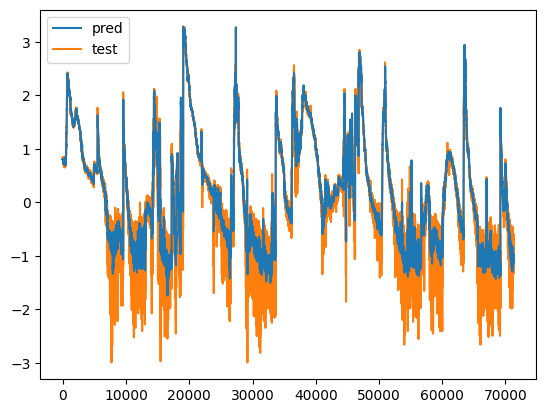

{'mae': 0.324340014321491, 'Persist_MAE': 0.4695376957847033, 'r2': 0.8537218753473381, 'mse': 0.17210894571423188, 'Model_Lag': 2.1, 'Persist_Lag': 3.4}
6


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
from utils.slice_rising import Slice_Rising
from utils.get_rising_metrics import Get_Rising_Metrics
# Build flattened feature matrix from your dataset
def build_flat_dataset(df, electron_range, forecast_out):
    X, y = [], []
    e150 = df["E150"].values
    e300 = df["E300"].values
    p_tot = df["P_tot"].values
    
    n = len(df) - electron_range - forecast_out
    for idx in range(n):
        window = np.column_stack([
            e150[idx:idx+electron_range],
            e300[idx:idx+electron_range],
            p_tot[idx:idx+electron_range]
        ]).flatten()                       # 24*3 = 72 features
        target = p_tot[idx + electron_range + forecast_out]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)
forecast_out = 6
X_train, y_train = build_flat_dataset(train_df, electron_range, forecast_out)
X_test, y_test = build_flat_dataset(test_df, electron_range, forecast_out)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)


y_pred_log = y_pred * p_tot_std + p_tot_mean
y_test_log = y_test * p_tot_std + p_tot_mean

mae = sk.metrics.mean_absolute_error(y_test_log, y_pred_log)
offset = electron_range + forecast_out
lr_aligned_df = test_df.iloc[offset : offset + len(y_pred)].copy()
lr_aligned_df["predicted"] = y_pred * p_tot_std + p_tot_mean
lr_aligned_df["original"]  = y_test * p_tot_std + p_tot_mean


plt.plot(np.linspace(0,len(y_pred),len(y_pred)), y_pred, label = 'pred')
plt.plot(np.linspace(0,len(y_pred),len(y_pred)), y_test, zorder = 1, label = 'test')
plt.legend()
plt.show()

print(Get_Rising_Metrics(lr_aligned_df, torres_merged_phases, forecast_out))
print(forecast_out)


